In [1]:
import os
import sys
import jax
import jax.numpy as np
import jax.tree as jtu

# Basic jax import
jax.config.update("jax_enable_x64", True)

# Check if running on remote, and set directory to where notebook is run
if jax.devices()[0].platform == "gpu":
    os.chdir("code/amigo_project/notebooks/calibration")
else:
    os.chdir("/Users/louis/PhD/Software/sandbox/amigo_project/notebooks/calibration")


# Add parent directories
paths = [os.path.abspath(os.path.join(os.getcwd(), path)) for path in ["..", "../.."]]
for path in paths:
    if path not in sys.path:
        sys.path.insert(0, path)

ERROR:2025-07-18 16:36:02,208:jax._src.xla_bridge:647: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/louis/miniconda3/envs/jax_gpu/lib/python3.13/site-packages/jax/_src/xla_bridge.py", line 645, in discover_pjrt_plugins
    plugin_module.initialize()
    ~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/home/louis/miniconda3/envs/jax_gpu/lib/python3.13/site-packages/jax_plugins/xla_cuda12/__init__.py", line 105, in initialize
    triton.register_compilation_handler(
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: module 'jax._src.lib.triton' has no attribute 'register_compilation_handler'


In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
        
# Plotting set up
%matplotlib inline
plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 120

inferno = mpl.colormaps["inferno"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]


inferno.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)

In [3]:
from amigo.files import get_files

# Set the program to use
program = "GO1843"

# Get the data
files = []
for file in get_files(f"../../data/calslope/{program}/", "calslope"):
    header = file["PRIMARY"].header

    # Only look at the F380M, F430M, and F480M filters
    if header["FILTER"] not in ["F380M", "F430M", "F480M"]:
        continue

    file["BADPIX"].data[:, -1:] = 1
    file["BADPIX"].data[58, 67] = 1
    file["BADPIX"].data[-2:] = 1
    file["BADPIX"].data[4, 45] = 1
    file["BADPIX"].data[47, 32] = 1

    files.append(file)


# 100k per hour
cost_per_sec = 100e3 / (60**2)
duration = np.array([file["PRIMARY"].header["DURATION"] for file in files]).sum()
print(f"Duration: {duration / (60 ** 2):.2f} Hours")
print(f"Estimated: $ {cost_per_sec * duration * 1e-3:.0f}k")

Duration: 2.56 Hours
Estimated: $ 256k


# Now we build our exposures and construct our model

In [4]:
from amigo.core_models import AmigoModel
from amigo.optical_models import AMIOptics
from amigo.detector_models import LinearDetector
from amigo.read_models import ReadModel
from amigo.model_fits import SplineVisFit
from amigo.vis_models import LogVisModel
from amigo.ramp_models import NonLinearRamp

# Load the cached states
file_path = "../../GPU_files/v_0.0.10"
load_dict = lambda x: np.load(f"{file_path}/{x}.npy", allow_pickle=True).item()
cal_files = load_dict("calibration")


# Get the exposures
exposures = [SplineVisFit(file, use_cov=True) for file in files]
exposures = [exp.add_badpix(cal_files["badpix"]) for exp in exposures]

# Get the model
model = AmigoModel(
    exposures=exposures,
    optics=AMIOptics(),
    detector=LinearDetector(),
    read=ReadModel(),
    ramp_model=NonLinearRamp(),
    vis_model=LogVisModel(load_dict("vis_basis"), n_basis=420),
    state=cal_files,
)

# Have a quick check to of the initial parameter guess fit

F430M Calibrator HD-205827 7


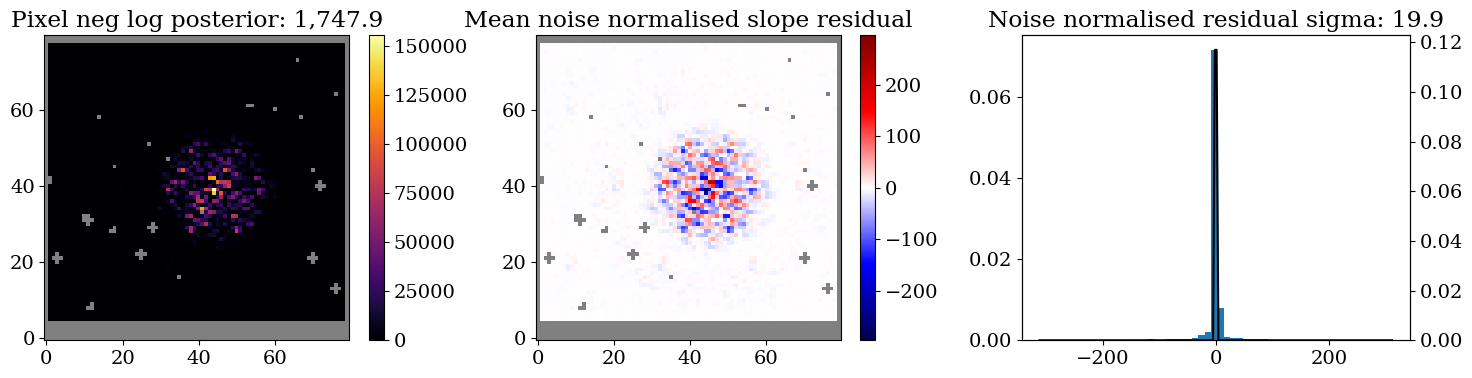

F380M Science HD-206893 4


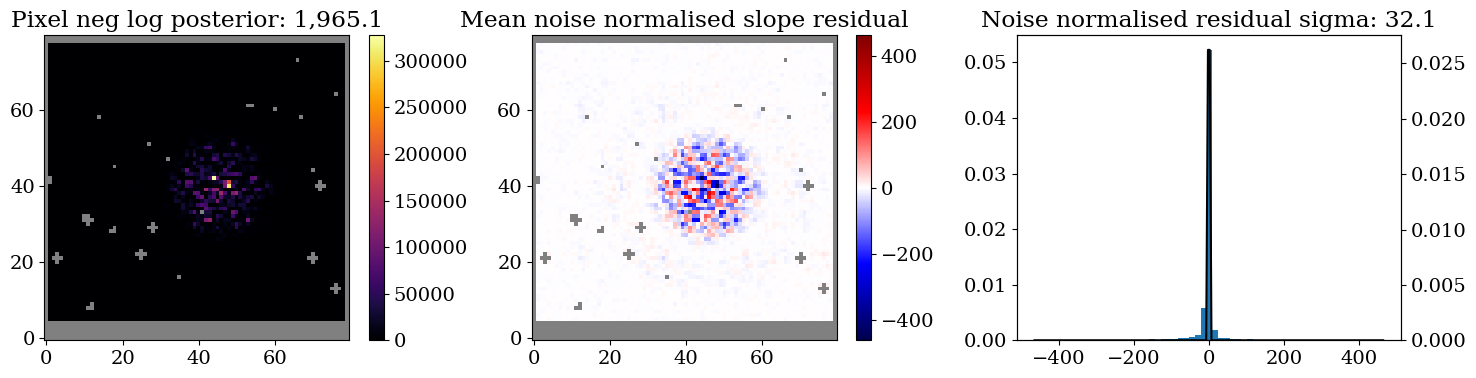

F480M Science HD-206893 11


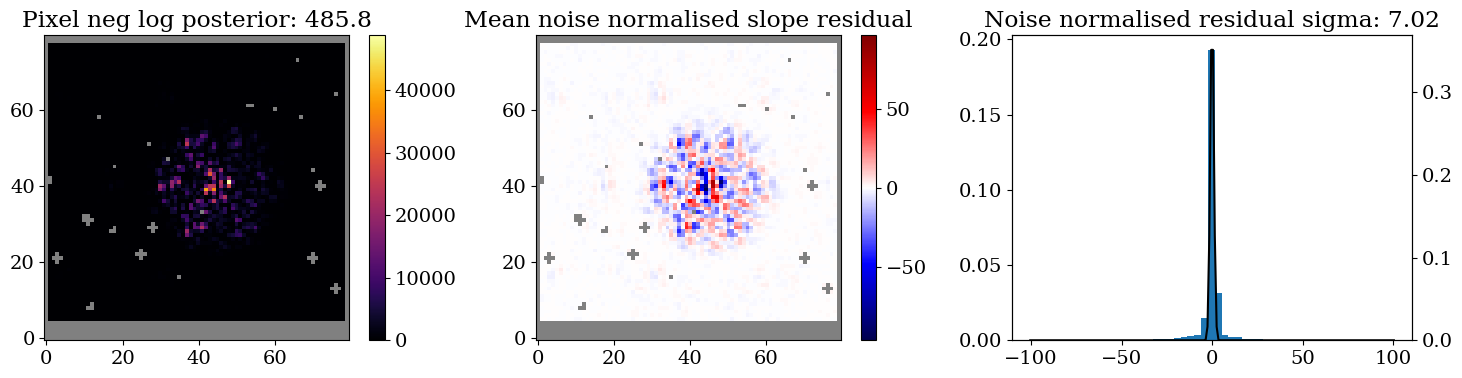

F480M Calibrator HD-205827 10


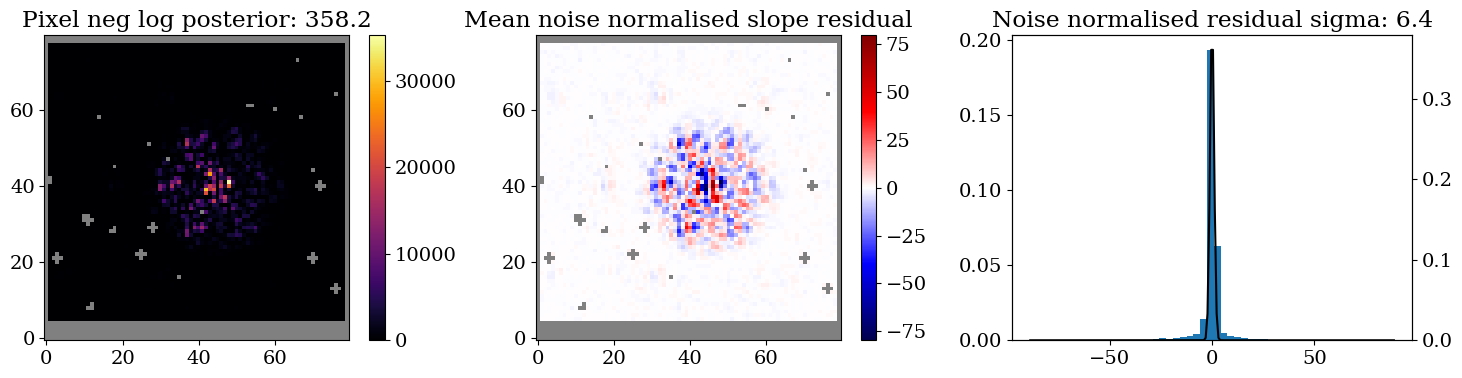

F430M Science HD-206893 8


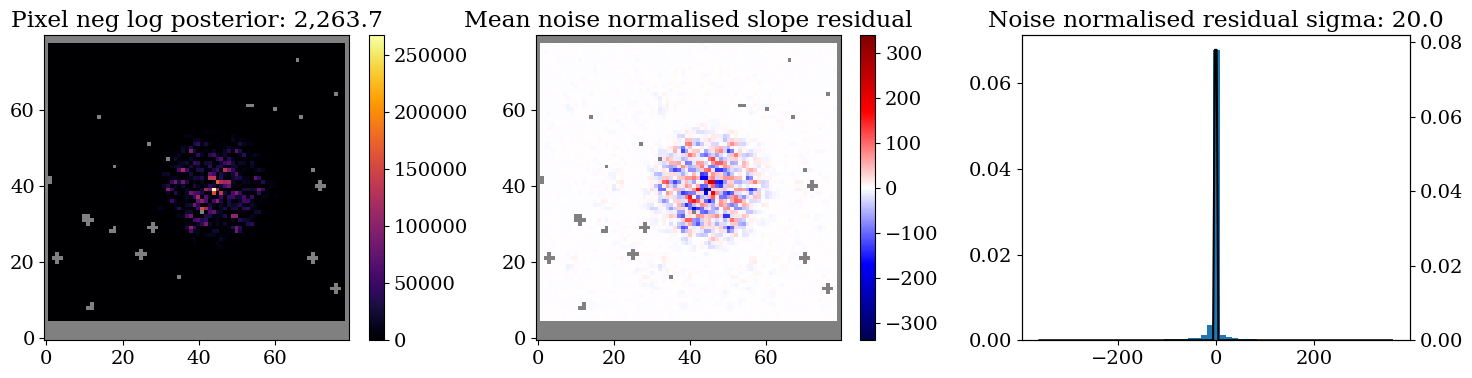

F380M Calibrator HD-205827 3


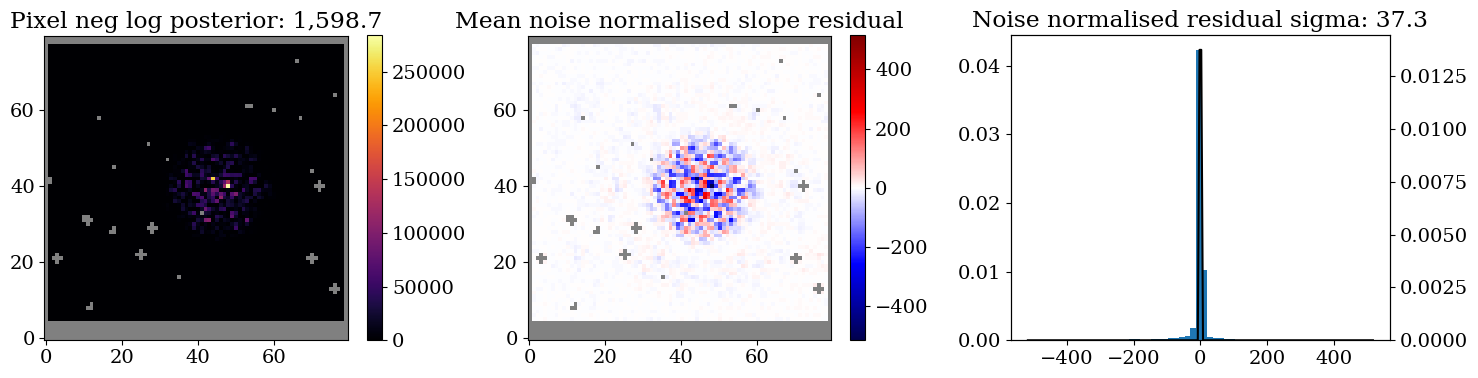

In [5]:
from amigo.plotting import summarise_fit

for exp in exposures:
    exp_type = "Calibrator" if exp.calibrator else "Science"
    print(exp.filter, exp_type, exp.star, exp.ngroups)
    summarise_fit(model, exp)

# Calibrated gradients & Fit the data

In [6]:
from amigo.fitting import Trainer, sgd, batch_exposures
import optax

def scheduler(lr, start, *args):
    shed_dict = {start: 1e32}
    for start, mul in args:
        shed_dict[start] = mul
    return optax.piecewise_constant_schedule(lr / 1e32, shed_dict)


base_sgd = lambda vals: optax.sgd(vals, nesterov=True, momentum=0.6)
base_adam = lambda vals: optax.adam(vals)

sgd = lambda lr, start, *schedule: base_sgd(scheduler(lr, start, *schedule))
adam = lambda lr, start, *schedule: base_adam(scheduler(lr, start, *schedule))


def loss_fn(model, exposure, args=None):
    return -np.nansum(exposure.mv_zscore(model)) / 80**2, ()


optimisers = {
    "positions": sgd(1e-1, 0),
    "fluxes": sgd(5e-2, 5),
    "aberrations": sgd(1e-1, 10),
    "spectra": sgd(1e-1, 20),
    "amplitudes": sgd(1e0, 30),
    "phases": sgd(1e0, 30),
}

# Calibrate the gradients via the fisher matrix
trainer = Trainer(loss_fn).populate_fishers(
    model=model,
    exposures=exposures,
    hessians=load_dict("jacobians")["hessian"],
    parameters=list(optimisers.keys()),
)

# Train the model
result = trainer.train(
    model=model,
    epochs=200,
    batches=batch_exposures(exposures, n_batch=2),
    optimisers=optimisers,
)

  0%|          | 0/200 [00:00<?, ?it/s]

Compiling Loss function...
Compiling Loss function...
Compiling update function...

Initial_loss Loss: 1,238.38
Estimated run time: 0:02:33
Full Time: 0:03:20
Final Loss: 15.12


# Examine our losses and parameter history

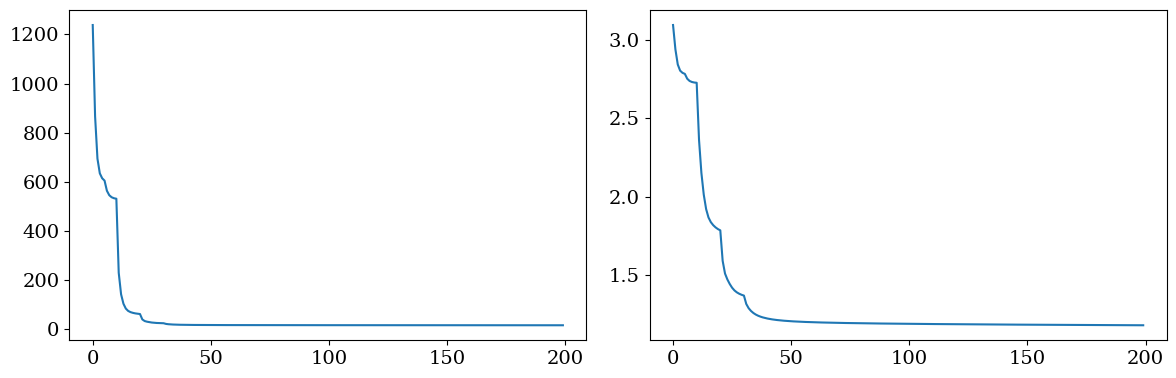

In [7]:
from amigo.plotting import plot

losses = np.array([v for v in result.losses.values()]).mean(0)

start = 0
stop = len(losses)
# stop = 50
xs = np.arange(start, stop)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(xs, losses[xs])
plt.subplot(1, 2, 2)

plt.plot(xs, np.log10(losses[xs]))
plt.tight_layout()
plt.show()

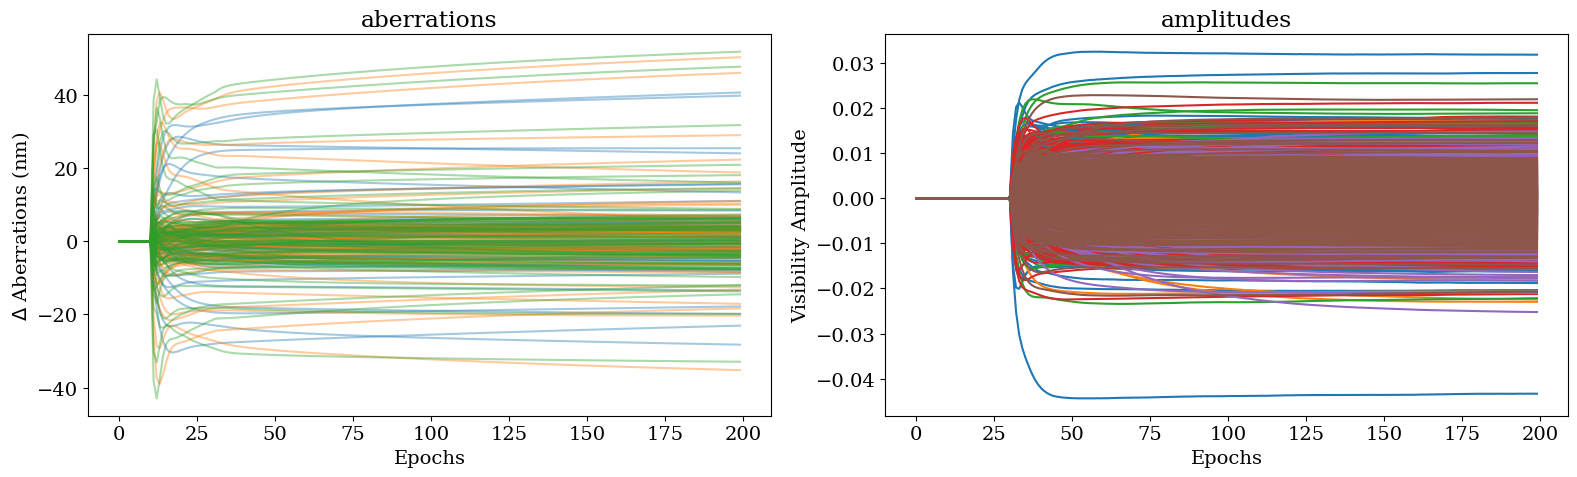

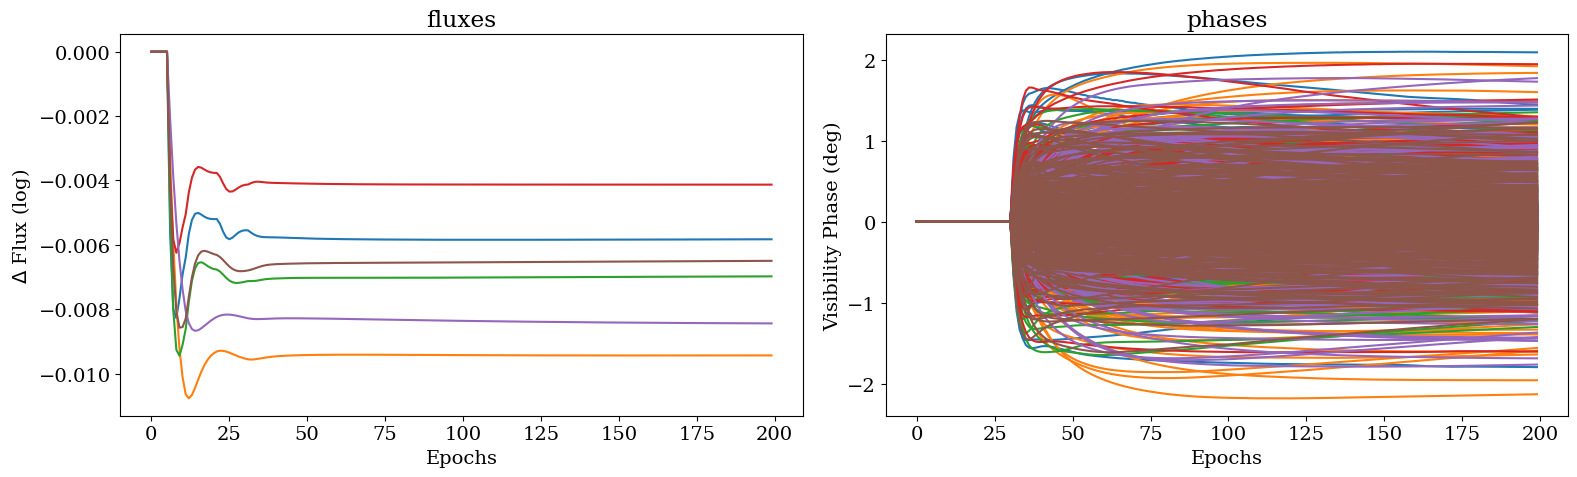

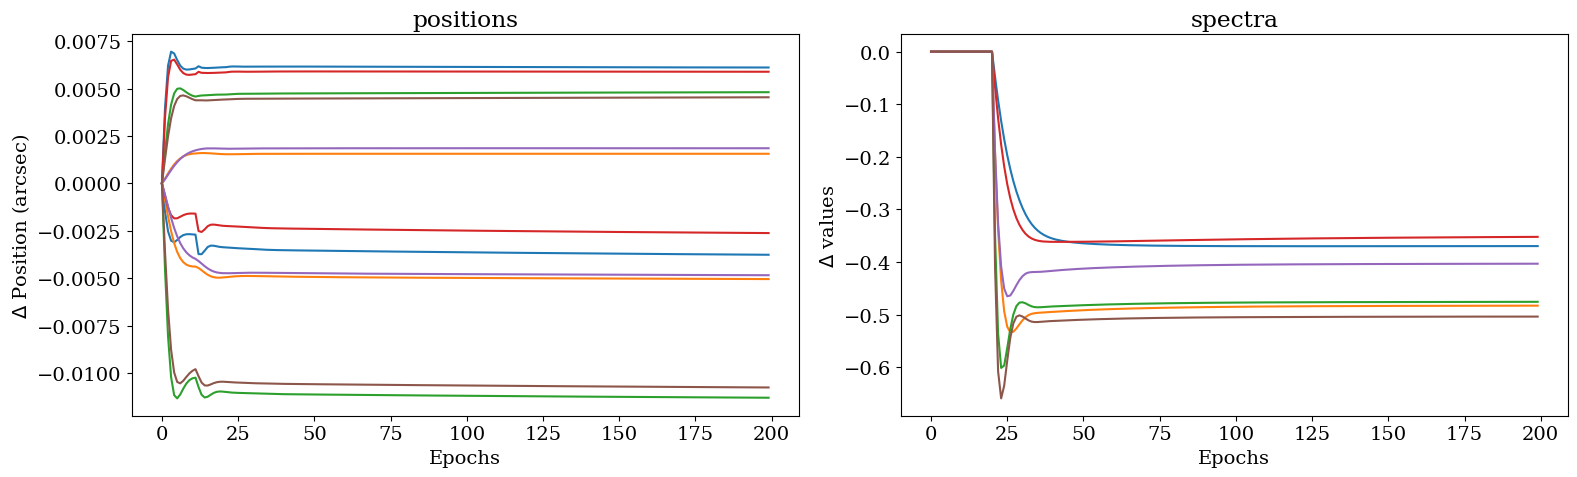

In [8]:
plot(result.history, start=0)#, end=25)

# EXPERIMENTAL: Final fit with BFGS

In [9]:
import equinox as eqx
import optimistix as optx
from amigo.core_models import ModelParams
from amigo.stats import decompose


@eqx.filter_jit
def fun(params, args):
    model, exp, model_params, proj_mats = args
    proj_fn = lambda x, P, x0: x0 + np.dot(P.T, x).reshape(x0.shape)
    model_params = jtu.map(proj_fn, params, proj_mats, model_params)
    return -np.nanmean(exp.mv_zscore(model_params.inject(model)))


params = ["amplitudes", "phases", "fluxes", "spectra"]
final_model = result.model
exp = exposures[0]

args_out, sols_out = {}, {}
for exp in exposures:
    opt_params, proj_mats = {}, {}
    for param in params:
        key = exp.map_param(param)
        opt_params[key] = final_model.get(key)
        fmat = -trainer.fishers[f"{exp.key}.{param}"]
        eig_vals, eig_vecs = decompose(fmat, normalise=False)
        proj_mats[key] = (eig_vals[None, :] ** -0.5) * eig_vecs

    opt_params = ModelParams(opt_params)
    proj_mats = ModelParams(proj_mats)

    #
    x0 = jtu.map(lambda x: np.zeros_like(x).flatten(), opt_params)
    args = (final_model, exp, opt_params, proj_mats)
    args_out[exp.key] = args

    print("Initial loss:", fun(x0, args))
    solver = optx.BFGS(rtol=1e-6, atol=1e-6)
    sol = optx.minimise(fun, solver, x0, args, throw=False, max_steps=2048)
    sols_out[exp.key] = sol

    print("Final loss:", fun(sol.value, args))
    print(sol.stats["num_steps"], sol.state.num_accepted_steps)
    print(optx.RESULTS[sol.result])
    print()

Initial loss: 15.251075719609512
Final loss: 15.249229002487859
588 191


Initial loss: 27.265712724991293
Final loss: 27.25660038345538
1002 321


Initial loss: 11.805994248779898
Final loss: 11.805633389049595
1066 219


Initial loss: 9.47420386167477
Final loss: 9.473876579328866
977 228


Initial loss: 19.34572085950289
Final loss: 19.34393608127599
792 218


Initial loss: 19.833124405383632
Final loss: 19.817922474435406
911 313




# Update the model with the BFGS final parameters

In [10]:
spectra = {}
for key, args in args_out.items():
    model, exp, model_params, proj_mats = args
    # TODO: Model this function into model params? Have it hold fishers?
    proj_fn = lambda x, P, x0: x0 + np.dot(P.T, x).reshape(x0.shape)
    model_params = jtu.map(proj_fn, sols_out[key].value, proj_mats, model_params)
    final_model = model_params.inject(final_model)

    # Spectra is joint-fit so we take the mean
    exp = args[1]
    spec = model_params.params[exp.map_param("spectra")]
    spec_key = exp.get_key("spectra")
    if spec_key not in spectra:
        spectra[spec_key] = [spec]
    else:
        spectra[spec_key].append(spec)

spectra = jtu.map(lambda x: np.array(x).mean(), spectra, is_leaf=lambda x: isinstance(x, list))
final_model = final_model.set("spectra", spectra)

final_state = {}
for key, values in result.state.items():
    final_state[key] = final_model.get(key)

# Check final fit

F380M Science HD-206893 4


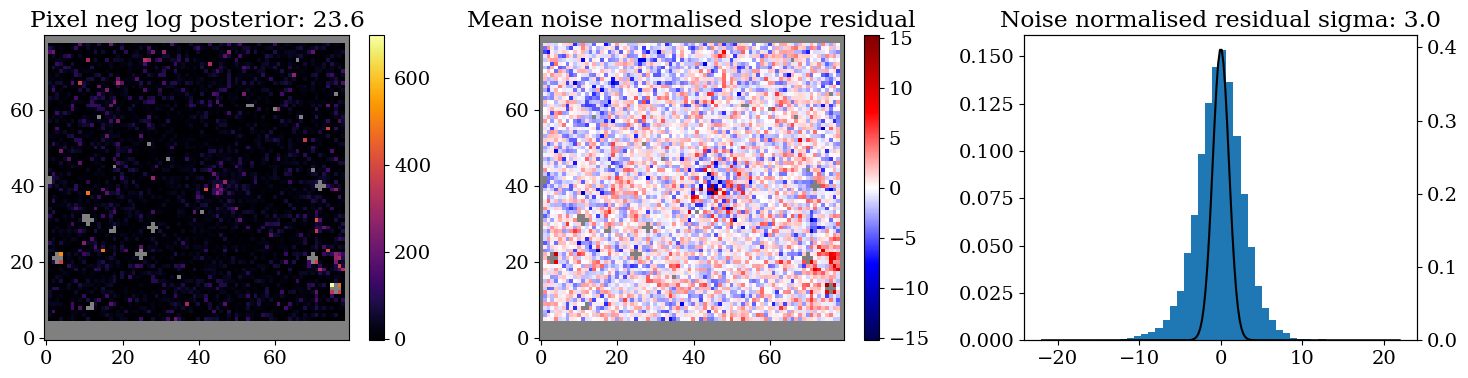

F380M Calibrator HD-205827 3


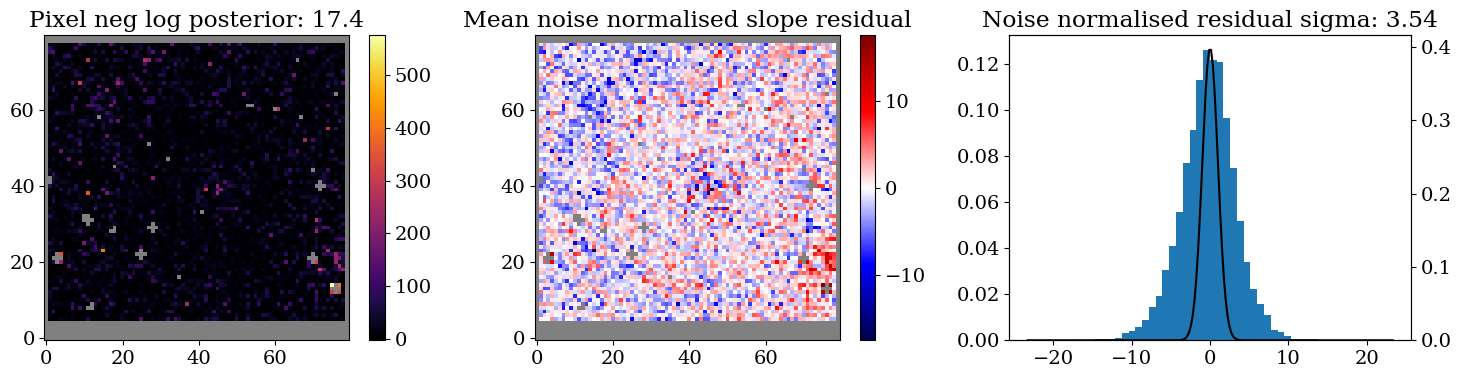

F430M Calibrator HD-205827 7


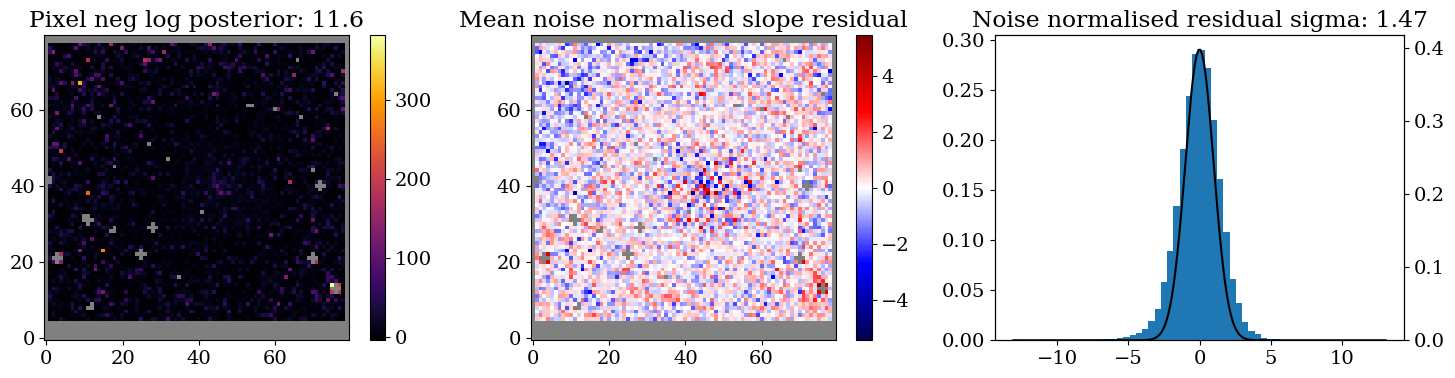

F430M Science HD-206893 8


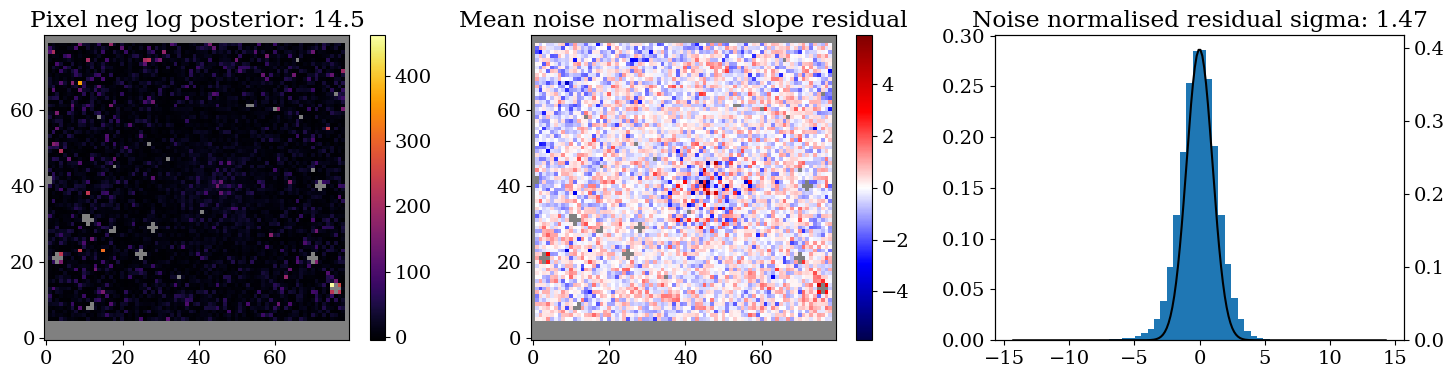

F480M Science HD-206893 11


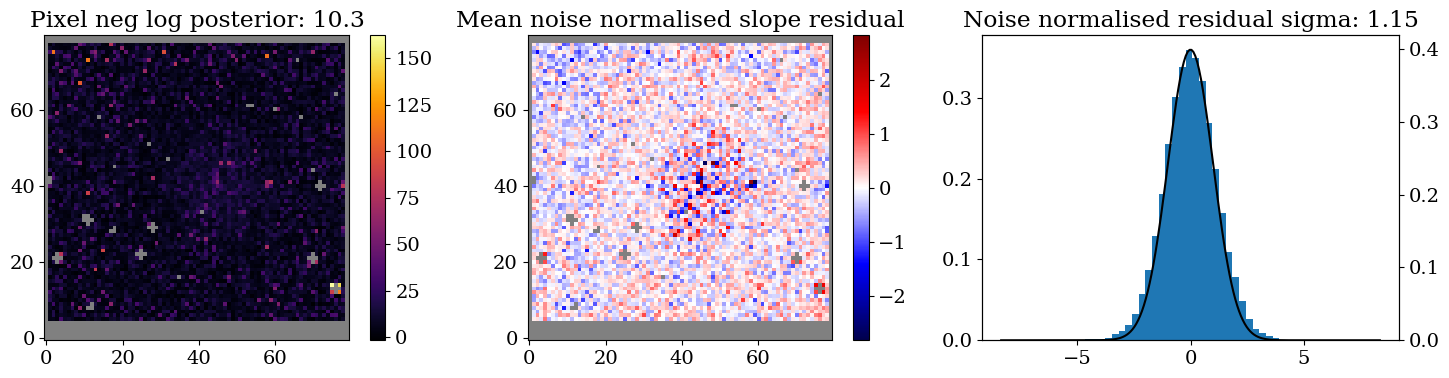

F480M Calibrator HD-205827 10


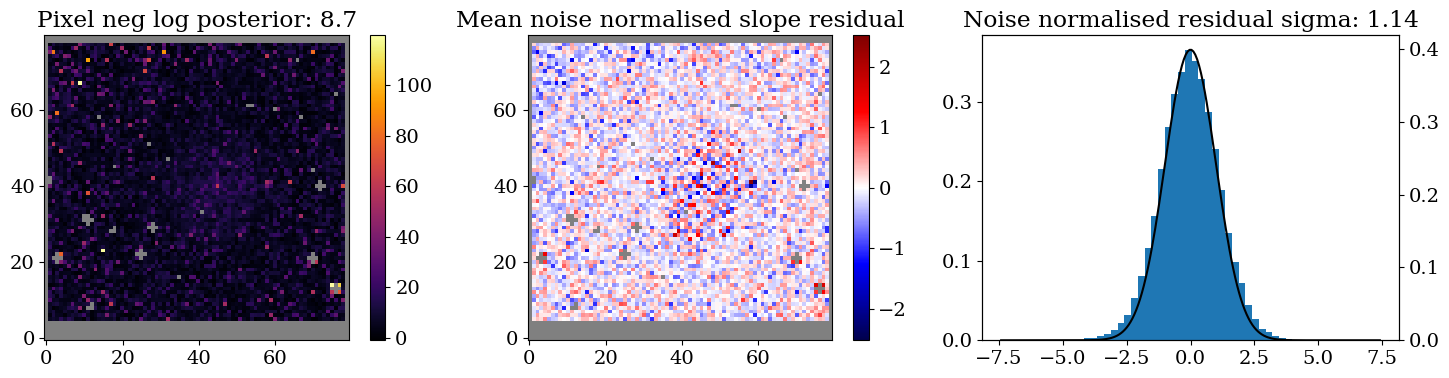

In [11]:
for filt in ["F380M", "F430M", "F480M"]:
    for exp in exposures:
        if exp.filter == filt:
            exp_type = "Calibrator" if exp.calibrator else "Science"
            print(exp.filter, exp_type, exp.star, exp.ngroups)
            summarise_fit(final_model, exp)

# Now calculate the Hessian of our loglikelihood at the MLE to estimate the parameter uncertainty

In [12]:
import jax.tree as jtu
from tqdm.notebook import tqdm
from amigo.fisher import FIM


fmats = {}
for exp in tqdm(exposures):
    loglike_fn = lambda model: -np.nansum(exp.loglike(model))
    params = [exp.map_param("amplitudes"), exp.map_param("phases")]
    fmat = FIM(final_model, params, loglike_fn, reduce_ram=True, batch_size=20)
    fmats[exp.get_key("phases")] = fmat

  0%|          | 0/6 [00:00<?, ?it/s]

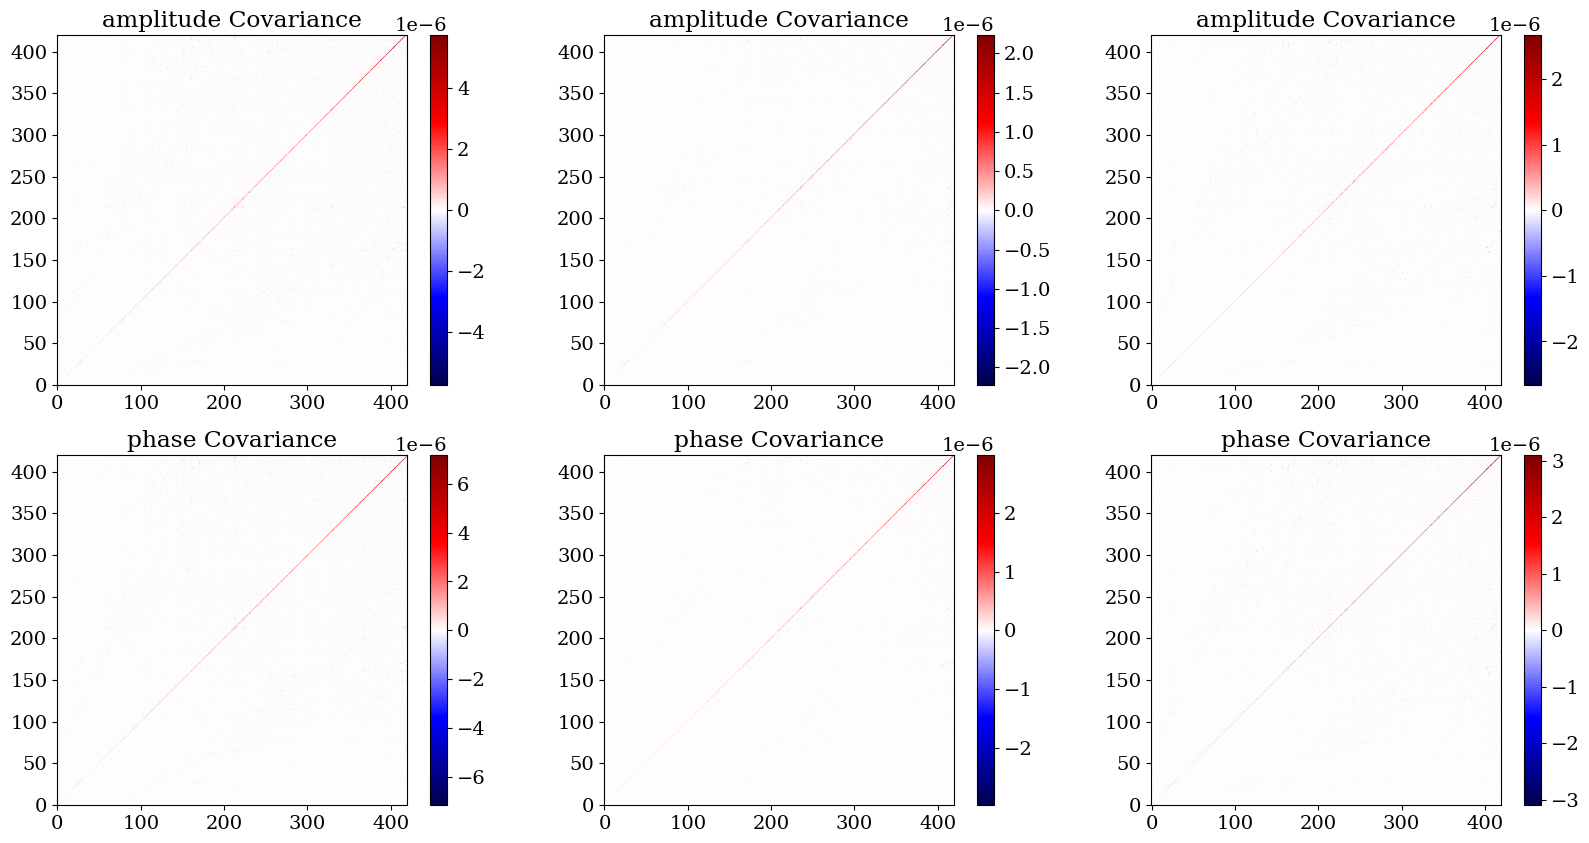

In [13]:
full_covs = jtu.map(lambda x: np.linalg.inv(x), fmats)

n = model.vis_model.n_basis
amp_covs = jtu.map(lambda x: x[:n, :n], full_covs)
phase_covs = jtu.map(lambda x: x[n:, n:], full_covs)

covs = {
    "amplitudes": amp_covs,
    "phases": phase_covs,
}

plt.figure(figsize=(20, 10))
for i, key in enumerate(amp_covs):
    if i > 5:
        break

    if i < 3:
        param = "amplitude"
        cov = amp_covs[key]
    else:
        param = "phase"
        cov = amp_covs[key]
    plt.subplot(2, 3, i + 1)
    plt.title(f"{param} Covariance")
    v = np.nanmax(np.abs(cov))
    plt.imshow(cov, seismic, vmin=-v, vmax=v)
    # plt.imshow(np.log10(np.abs(cov)), inferno)
    plt.colorbar()
plt.show()

# Finally, save our fit outputs

In [14]:
stars = list(set(exp.star for exp in exposures))
filters = ["F380M", "F430M", "F480M"]

for star in stars:
    print(f"{star}")
    for filt in filters:
        for exp in exposures:
            if exp.star == star and exp.filter == filt:
                log_flux = model.get(exp.map_param("fluxes"))
                flux = (10 ** log_flux) * 1e-3
                print(f"  {filt}: {flux:.2f}x10^3 Photons/Int")
    print()


HD-206893
  F380M: 279.83x10^3 Photons/Int
  F430M: 181.30x10^3 Photons/Int
  F480M: 163.87x10^3 Photons/Int

HD-205827
  F380M: 338.96x10^3 Photons/Int
  F430M: 212.62x10^3 Photons/Int
  F480M: 168.71x10^3 Photons/Int



In [ ]:
fit_outputs = {
    "n_basis": final_model.vis_model.n_basis,
}

for exp in exposures:
    get_fn = lambda param: final_model.get(exp.map_param(param))
    fit_outputs[exp.key] = {
        "star": exp.star,
        "calibrator": exp.calibrator,
        "filter": exp.filter,
        "parang": exp.parang,
        "defocus": final_model.get(exp.map_param("defocus")),
        "n_basis": final_model.vis_model.n_basis,
        "fishers": fmats[exp.get_key("phases")],
        "amp_cov": amp_covs[exp.get_key("phases")],
        "phase_cov": phase_covs[exp.get_key("phases")],
        **{param: get_fn(param) for param in final_state.keys()},
    }

np.save(f"../../GPU_files/results/{program}/vis_fit", fit_outputs, allow_pickle=True)

: 